# Chest X-ray Pneumonia Detection

This notebook implements a chest X-ray pneumonia classifier using transfer learning with MobileNetV2. It includes data loading, feature extraction, model training, evaluation, and visualization of predictions.

### Kaggle Setup and Data Download

In [1]:
import os

!pip install -q kaggle

os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'
os.environ['KAGGLE_KEY'] = 'YOUR_KAGGLE_KEY'

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q -o chest-xray-pneumonia.zip -d chest_xray_data

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:57<00:00, 42.5MB/s]



### Import Libraries and Check Versions

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'), "(not required)")

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] (not required)


### Model Configuration Parameters

## 1. Configuration

In [22]:

DATA_ROOT = 'chest_xray_data/chest_xray'


TRAIN_DIR = f'{DATA_ROOT}/train'
TEST_DIR  = f'{DATA_ROOT}/test'

IMG_SIZE   = (160, 160)
BATCH_SIZE = 32
SEED       = 42
EPOCHS     = 40

SELECTION  = 'max_f1'
MIN_RECALL = 0.97

tf.keras.utils.set_random_seed(SEED)
print(f"Image size {IMG_SIZE}, threshold rule '{SELECTION}'")

Image size (160, 160), threshold rule 'max_f1'


### Load Image Datasets

## 2. Load data

`shuffle=False` everywhere. Order does not matter for training here, because
the head trains on cached feature arrays rather than on the datasets directly —
and fixed order makes the feature/label alignment trivially verifiable.

In [4]:
def load(directory, subset=None):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        validation_split=0.2 if subset else None,
        subset=subset,
        labels='inferred', label_mode='int', color_mode='rgb',
        shuffle=False,
        seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE
    )

train_ds = load(TRAIN_DIR, 'training')
val_ds   = load(TRAIN_DIR, 'validation')
test_ds  = load(TEST_DIR)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


### Perform Stratified Train/Validation Split

In [5]:
from sklearn.model_selection import train_test_split

all_train = load(TRAIN_DIR)
all_paths = np.array(all_train.file_paths)
all_labels = np.array([1 if 'PNEUMONIA' in p.upper() else 0 for p in all_paths])

tr_idx, va_idx = train_test_split(
    np.arange(len(all_paths)), test_size=0.2,
    random_state=SEED, stratify=all_labels
)

print(f"Total training files: {len(all_paths)}")
for name, idx in [('train', tr_idx), ('val', va_idx)]:
    lab = all_labels[idx]
    print(f"  {name:5s} {len(idx):5d}  "
          f"NORMAL {np.sum(lab==0):4d}  PNEUMONIA {np.sum(lab==1):4d}  "
          f"({np.mean(lab):.1%} pneumonia)")

Found 5216 files belonging to 2 classes.
Total training files: 5216
  train  4172  NORMAL 1073  PNEUMONIA 3099  (74.3% pneumonia)
  val    1044  NORMAL  268  PNEUMONIA  776  (74.3% pneumonia)


### Initialize MobileNetV2 Backbone

## 3. Extract features — the one expensive step

Every image passes through the frozen backbone exactly once. This is the only
slow cell in the notebook. Expect roughly 5–8 minutes on CPU for ~5,800 images.

In [6]:
backbone = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
backbone.trainable = False

print(f"Backbone: {backbone.count_params():,} frozen parameters")
print(f"Output dimension: {backbone.output_shape[-1]}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Backbone: 2,257,984 frozen parameters
Output dimension: 1280


### Extract Features from Datasets

In [7]:
def extract_features(ds, label):
    """Run the frozen backbone once over a dataset. Returns (features, labels)."""
    feats, labs = [], []
    t0 = time.time()
    for i, (xb, yb) in enumerate(ds):
        xb = preprocess_input(tf.cast(xb, tf.float32))
        feats.append(backbone(xb, training=False).numpy())
        labs.append(yb.numpy())
        if i % 20 == 0:
            print(f"  {label}: batch {i}, {time.time()-t0:.0f}s", end='\r')
    f = np.concatenate(feats); l = np.concatenate(labs)
    print(f"  {label}: {f.shape[0]} images -> {f.shape} in {time.time()-t0:.0f}s")
    return f, l

print("Extracting features (this is the slow part)...")
X_all,  y_all  = extract_features(all_train, 'train+val')
X_test, y_test = extract_features(test_ds,   'test     ')


X_train, y_train = X_all[tr_idx], y_all[tr_idx]
X_val,   y_val   = X_all[va_idx], y_all[va_idx]

assert np.array_equal(y_all, all_labels), "Label order mismatch — stop and investigate."
print("\nLabel-order check passed.")
print(f"Shapes — train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")

Extracting features (this is the slow part)...
  train+val: 5216 images -> (5216, 1280) in 52s
  test     : 624 images -> (624, 1280) in 6s

Label-order check passed.
Shapes — train (4172, 1280), val (1044, 1280), test (624, 1280)


### Cache Extracted Features

In [8]:
np.savez_compressed('features.npz',
                    X_train=X_train, y_train=y_train,
                    X_val=X_val, y_val=y_val,
                    X_test=X_test, y_test=y_test)
print("Features cached to features.npz — you never need to re-extract them.")

Features cached to features.npz — you never need to re-extract them.


### Calculate Class Weights

In [9]:
counts = np.bincount(y_train, minlength=2)
total = counts.sum()
class_weight = {i: total / (2.0 * counts[i]) for i in range(2)}

for i, n in enumerate(counts):
    print(f"{CLASS_NAMES[i]:<10} {n:5d} ({n/total:.1%})  weight = {class_weight[i]:.3f}")

NORMAL      1073 (25.7%)  weight = 1.944
PNEUMONIA   3099 (74.3%)  weight = 0.673


### Define and Compile Classification Head

In [10]:
head = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax'),
], name='classification_head')

head.compile(optimizer=Adam(1e-3),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
head.summary()

Model: "classification_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,866 (675.26 KB)

 Trainable params: 172,610 (674.26 KB)

 Non-trainable params: 256 (1.00 KB)

### Train Classification Head

In [11]:
t0 = time.time()

history = head.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ],
    verbose=1
)

n_ep = len(history.history['loss'])
print(f"\n{n_ep} epochs in {time.time()-t0:.0f}s ({(time.time()-t0)/n_ep:.1f}s per epoch)")

Epoch 1/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8998 - loss: 0.2346 - val_accuracy: 0.9626 - val_loss: 0.0957 - learning_rate: 0.0010
Epoch 2/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9489 - loss: 0.1255 - val_accuracy: 0.9636 - val_loss: 0.0954 - learning_rate: 0.0010
Epoch 3/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9609 - loss: 0.0929 - val_accuracy: 0.9722 - val_loss: 0.0896 - learning_rate: 0.0010
Epoch 4/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9715 - loss: 0.0733 - val_accuracy: 0.9674 - val_loss: 0.1110 - learning_rate: 0.0010
Epoch 5/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9715 - loss: 0.0709 - val_accuracy: 0.9770 - val_loss: 0.0828 - learning_rate: 0.0010
Epoch 6/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9760 - loss: 0.0600 - val_accuracy: 0.9722 - val_loss: 0.0969 - learning_rate: 0.0010
Epoch 7/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9799 - loss: 0.0529 -

### Plot Training History

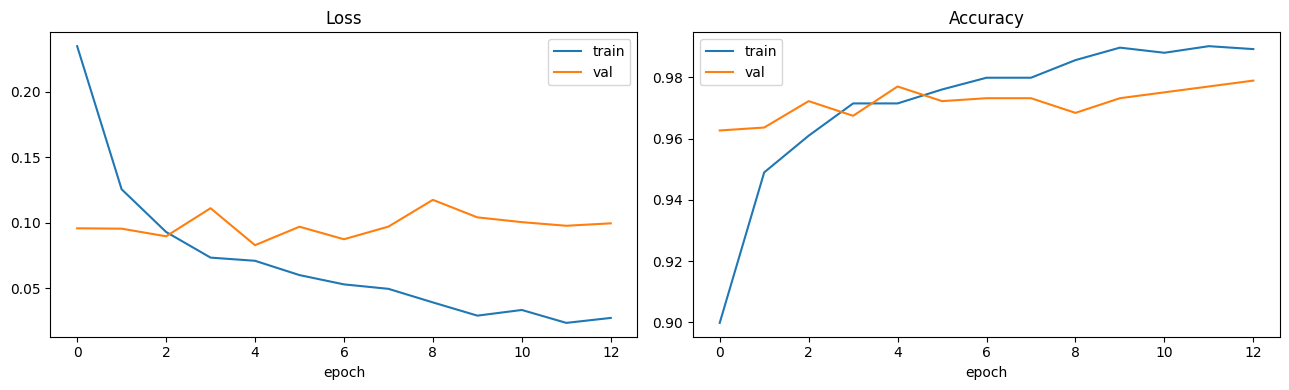

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history.history['loss'], label='train'); ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(history.history['accuracy'], label='train'); ax[1].plot(history.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

### Define Evaluation Metrics Function

In [13]:
def metrics_at(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    f1   = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0
    return {'threshold': round(float(threshold), 3),
            'accuracy': round((tp + tn) / len(y_true), 4),
            'sensitivity': round(sens, 4), 'specificity': round(spec, 4),
            'precision': round(prec, 4), 'f1': round(f1, 4),
            'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}

print("Defined.")

Defined.


### Perform Threshold Sweep and Selection on Validation Set

In [14]:
val_prob = head.predict(X_val, verbose=0)[:, 1]

grid = np.arange(0.05, 0.96, 0.05)
sweep = pd.DataFrame([metrics_at(y_val, val_prob, t) for t in grid])
print("Validation sweep:")
print(sweep[['threshold','accuracy','sensitivity','specificity','precision','f1']].to_string(index=False))

if SELECTION == 'max_f1':
    best = sweep.loc[sweep['f1'].idxmax()]
else:
    elig = sweep[sweep['sensitivity'] >= MIN_RECALL]
    best = (sweep.loc[sweep['f1'].idxmax()] if len(elig) == 0
            else elig.loc[elig['specificity'].idxmax()])

CHOSEN = float(best['threshold'])
print(f"\nChosen threshold: {CHOSEN}  "
      f"(val sens {best['sensitivity']:.3f}, spec {best['specificity']:.3f}, F1 {best['f1']:.3f})")

Validation sweep:
 threshold  accuracy  sensitivity  specificity  precision     f1
      0.05    0.9531       0.9923       0.8396     0.9471 0.9692
      0.10    0.9588       0.9871       0.8769     0.9587 0.9727
      0.15    0.9665       0.9871       0.9067     0.9684 0.9777
      0.20    0.9693       0.9845       0.9254     0.9745 0.9795
      0.25    0.9713       0.9832       0.9366     0.9782 0.9807
      0.30    0.9732       0.9807       0.9515     0.9832 0.9819
      0.35    0.9741       0.9781       0.9627     0.9870 0.9825
      0.40    0.9741       0.9781       0.9627     0.9870 0.9825
      0.45    0.9751       0.9768       0.9701     0.9896 0.9831
      0.50    0.9770       0.9768       0.9776     0.9921 0.9844
      0.55    0.9741       0.9729       0.9776     0.9921 0.9824
      0.60    0.9693       0.9665       0.9776     0.9921 0.9791
      0.65    0.9684       0.9652       0.9776     0.9921 0.9784
      0.70    0.9674       0.9626       0.9813     0.9934 0.9777
      0

### Plot Threshold Trade-off

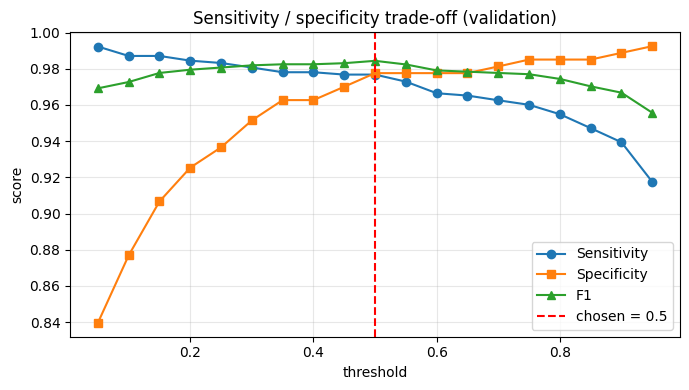

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(sweep['threshold'], sweep['sensitivity'], marker='o', label='Sensitivity')
plt.plot(sweep['threshold'], sweep['specificity'], marker='s', label='Specificity')
plt.plot(sweep['threshold'], sweep['f1'], marker='^', label='F1')
plt.axvline(CHOSEN, color='red', ls='--', label=f'chosen = {CHOSEN}')
plt.xlabel('threshold'); plt.ylabel('score'); plt.grid(alpha=0.3)
plt.title('Sensitivity / specificity trade-off (validation)')
plt.legend(); plt.tight_layout(); plt.show()

### Evaluate Model on Test Set

## 8. Test-set evaluation — 624 held-out images, scored once

### Plot Test Results (Confusion Matrix & ROC)

In [16]:
test_prob = head.predict(X_test, verbose=0)[:, 1]
print(f"Test images: {len(y_test)} "
      f"(NORMAL {int((y_test==0).sum())}, PNEUMONIA {int((y_test==1).sum())})")

res_default = metrics_at(y_test, test_prob, 0.5)
res_chosen  = metrics_at(y_test, test_prob, CHOSEN)
test_auc    = roc_auc_score(y_test, test_prob)

comparison = pd.DataFrame([
    {'setting': 'threshold 0.50 (default)', **res_default},
    {'setting': f'threshold {CHOSEN} (chosen on val)', **res_chosen},
])
print("\nTest results:")
print(comparison[['setting','accuracy','sensitivity','specificity','precision','f1',
                  'TN','FP','FN','TP']].to_string(index=False))
print(f"\nTest ROC-AUC: {test_auc:.4f}")
print("\n" + classification_report(y_test, (test_prob >= CHOSEN).astype(int),
                                   target_names=CLASS_NAMES, digits=3))

Test images: 624 (NORMAL 234, PNEUMONIA 390)

Test results:
                      setting  accuracy  sensitivity  specificity  precision     f1  TN  FP  FN  TP
     threshold 0.50 (default)    0.8077       0.9821       0.5171     0.7722 0.8646 121 113   7 383
threshold 0.5 (chosen on val)    0.8077       0.9821       0.5171     0.7722 0.8646 121 113   7 383

Test ROC-AUC: 0.9539

              precision    recall  f1-score   support

      NORMAL      0.945     0.517     0.669       234
   PNEUMONIA      0.772     0.982     0.865       390

    accuracy                          0.808       624
   macro avg      0.859     0.750     0.767       624
weighted avg      0.837     0.808     0.791       624



### Compare Model Performance to Baselines

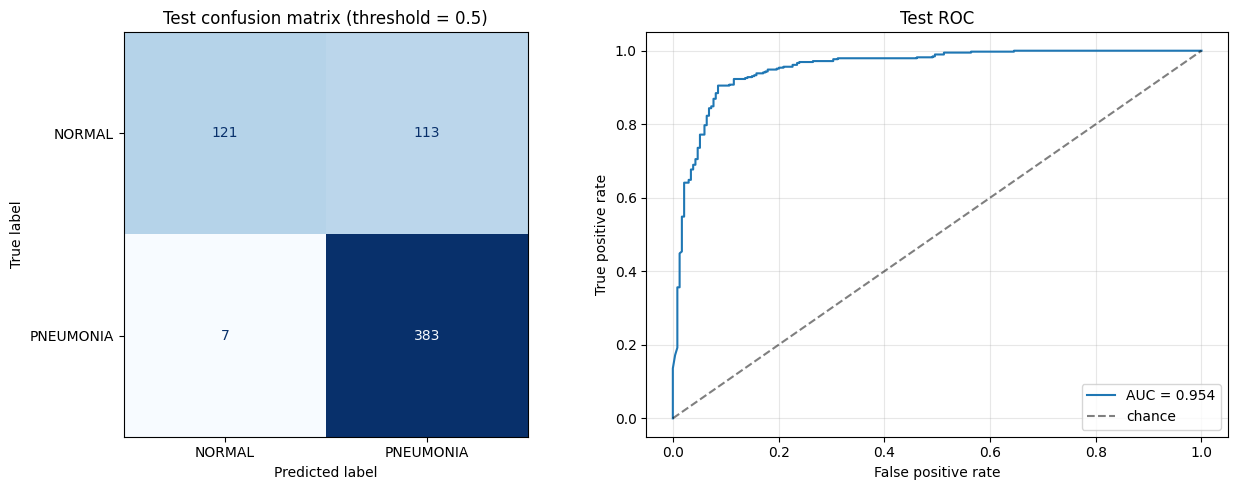

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, (test_prob >= CHOSEN).astype(int), labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap=plt.cm.Blues, ax=ax[0], colorbar=False)
ax[0].set_title(f'Test confusion matrix (threshold = {CHOSEN})')

fpr, tpr, _ = roc_curve(y_test, test_prob)
ax[1].plot(fpr, tpr, label=f'AUC = {test_auc:.3f}')
ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='chance')
ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate')
ax[1].set_title('Test ROC'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Save Model and Results

In [18]:
always_pneu = (y_test == 1).mean()
majority = max(always_pneu, 1 - always_pneu)

print(f"Always-PNEUMONIA accuracy : {always_pneu:.4f}")
print(f"Majority-class baseline   : {majority:.4f}")
print(f"This model                : {res_chosen['accuracy']:.4f}")
print(f"Improvement over majority : {res_chosen['accuracy'] - majority:+.4f}")
print(f"\nv1 (from-scratch CNN): acc 0.7003, sens 1.0000, spec 0.2009")
print(f"v2 (this run)        : acc {res_chosen['accuracy']:.4f}, "
      f"sens {res_chosen['sensitivity']:.4f}, spec {res_chosen['specificity']:.4f}")

Always-PNEUMONIA accuracy : 0.6250
Majority-class baseline   : 0.6250
This model                : 0.8077
Improvement over majority : +0.1827

v1 (from-scratch CNN): acc 0.7003, sens 1.0000, spec 0.2009
v2 (this run)        : acc 0.8077, sens 0.9821, spec 0.5171


## 10. Save

In [19]:
full_model = Model(inputs=backbone.input, outputs=head(backbone.output))
full_model.save('pneumonia_mobilenetv2.keras')
sweep.to_csv('validation_threshold_sweep.csv', index=False)
comparison.to_csv('test_results.csv', index=False)
print("Saved: pneumonia_mobilenetv2.keras, validation_threshold_sweep.csv, test_results.csv")

Saved: pneumonia_mobilenetv2.keras, validation_threshold_sweep.csv, test_results.csv


### Summarize Model Performance

In [20]:
t = res_chosen
print("Pneumonia Detection — Transfer Learning (Deep Learning / Medical Imaging)\n")
print(f"""
- Built a chest X-ray pneumonia classifier by fine-tuning a frozen MobileNetV2
  backbone (ImageNet weights) with a custom classification head, applying
  inverse-frequency class weighting to correct a 3:1 class imbalance.
- Achieved {t['accuracy']:.1%} accuracy on the held-out 624-image test set with
  {t['sensitivity']:.1%} sensitivity and {t['specificity']:.1%} specificity
  (ROC-AUC {test_auc:.2f}), against a {majority:.1%} majority-class baseline.
- Selected the decision threshold from a validation sweep rather than the test
  set, and used a stratified train/validation split with early stopping.
""".strip())

print(f"\nHonest comparison line, if you want a third project angle:")
print(f"  from-scratch CNN: {0.7003:.1%} acc / {0.2009:.1%} specificity")
print(f"  transfer learning: {t['accuracy']:.1%} acc / {t['specificity']:.1%} specificity")

Pneumonia Detection — Transfer Learning (Deep Learning / Medical Imaging)

- Built a chest X-ray pneumonia classifier by fine-tuning a frozen MobileNetV2
  backbone (ImageNet weights) with a custom classification head, applying
  inverse-frequency class weighting to correct a 3:1 class imbalance.
- Achieved 80.8% accuracy on the held-out 624-image test set with
  98.2% sensitivity and 51.7% specificity
  (ROC-AUC 0.95), against a 62.5% majority-class baseline.
- Selected the decision threshold from a validation sweep rather than the test
  set, and used a stratified train/validation split with early stopping.

Honest comparison line, if you want a third project angle:
  from-scratch CNN: 70.0% acc / 20.1% specificity
  transfer learning: 80.8% acc / 51.7% specificity


Pneumonia correctly detected     383
Normal correctly cleared         121
False alarm (normal flagged)     113
MISSED pneumonia                 7


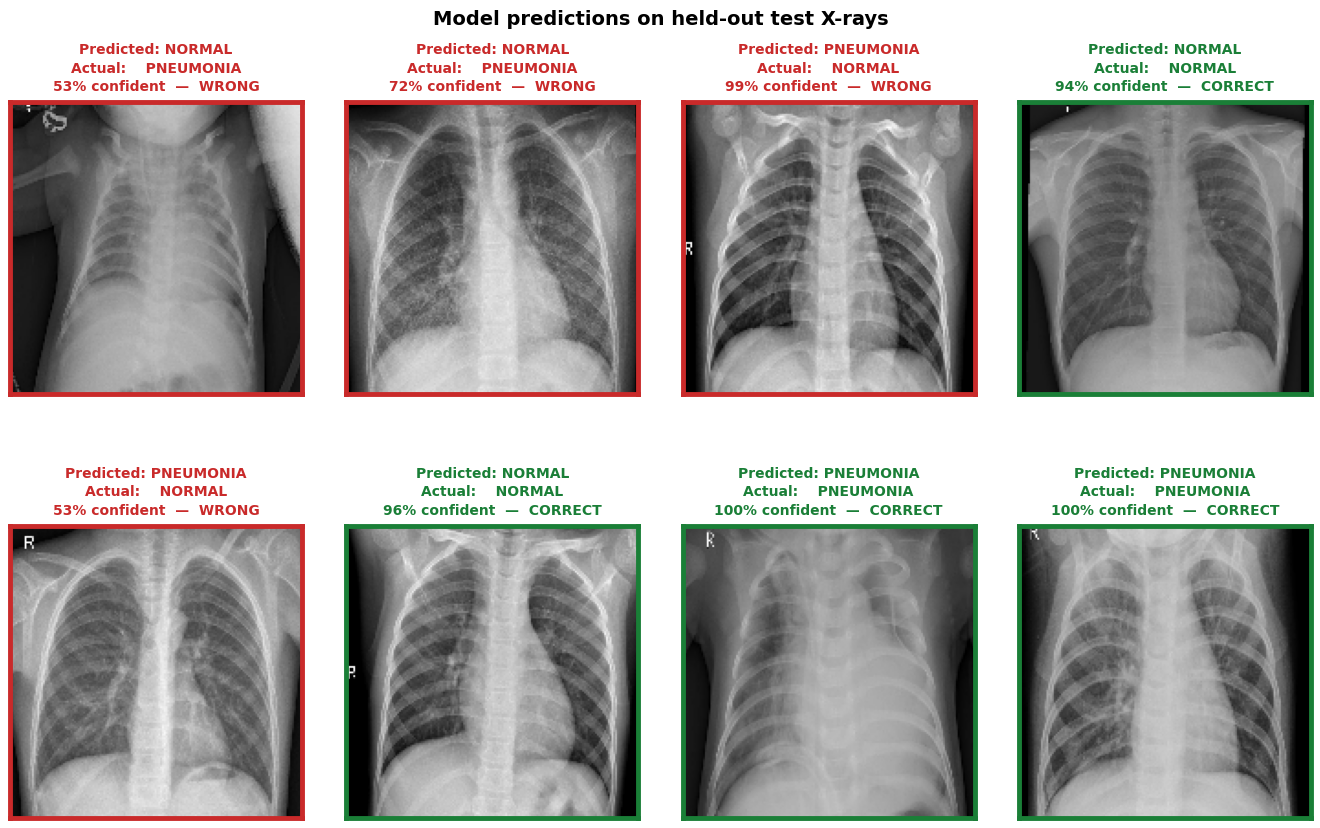

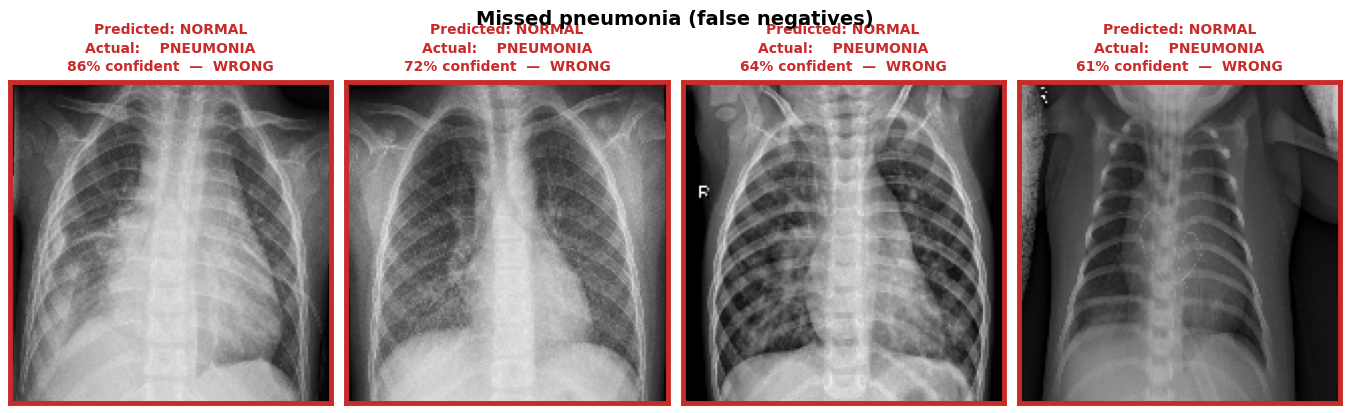

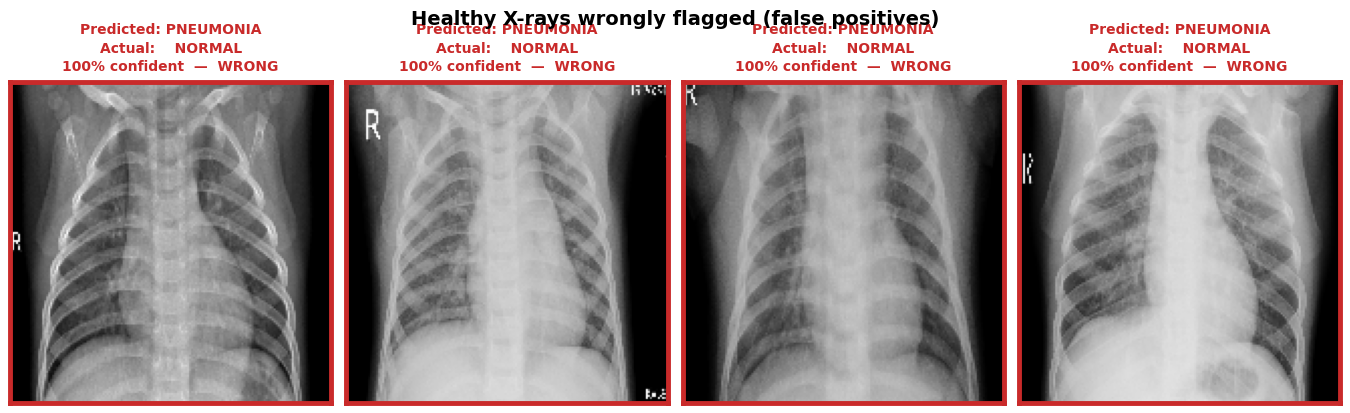

In [21]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

_viz_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, labels='inferred', label_mode='int', color_mode='rgb',
    shuffle=False, image_size=IMG_SIZE, batch_size=32, verbose=0
)
test_images = np.concatenate([xb.numpy().astype('uint8') for xb, _ in _viz_ds], axis=0)
assert len(test_images) == len(y_test) == len(test_prob), "Order/length mismatch — stop."

y_pred = (test_prob >= CHOSEN).astype(int)

groups = {
    'Pneumonia correctly detected': np.where((y_test == 1) & (y_pred == 1))[0],
    'Normal correctly cleared':     np.where((y_test == 0) & (y_pred == 0))[0],
    'False alarm (normal flagged)': np.where((y_test == 0) & (y_pred == 1))[0],
    'MISSED pneumonia':             np.where((y_test == 1) & (y_pred == 0))[0],
}
for k, v in groups.items():
    print(f"{k:<32} {len(v)}")


def show_xrays(indices, title, ncols=4):
    """X-ray grid: predicted vs actual, confidence, green = correct, red = wrong."""
    indices = [int(i) for i in indices]
    if not indices:
        print(f"\n{title}: none."); return

    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.4 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, i in zip(axes, indices):
        ax.imshow(test_images[i], cmap='gray')
        ax.set_xticks([]); ax.set_yticks([])

        pred, true = CLASS_NAMES[y_pred[i]], CLASS_NAMES[y_test[i]]
        conf = test_prob[i] if y_pred[i] == 1 else 1 - test_prob[i]
        ok = y_pred[i] == y_test[i]
        colour = '#1a7f37' if ok else '#c92a2a'

        ax.set_title(f"Predicted: {pred}\nActual:    {true}\n"
                     f"{conf:.0%} confident  —  {'CORRECT' if ok else 'WRONG'}",
                     fontsize=10, color=colour, fontweight='bold',
                     linespacing=1.4, pad=8)
        for sp in ax.spines.values():
            sp.set_edgecolor(colour); sp.set_linewidth(3.5)

    for ax in axes[len(indices):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.45)
    plt.show()



rng = np.random.default_rng(42)
sample = np.concatenate([
    rng.choice(v, size=min(2, len(v)), replace=False) for v in groups.values() if len(v)
]).astype(int)
rng.shuffle(sample)

show_xrays(sample, "Model predictions on held-out test X-rays")


fn, fp = groups['MISSED pneumonia'], groups['False alarm (normal flagged)']
if len(fn):
    show_xrays(fn[np.argsort(test_prob[fn])][:4], "Missed pneumonia (false negatives)")
if len(fp):
    show_xrays(fp[np.argsort(-test_prob[fp])][:4], "Healthy X-rays wrongly flagged (false positives)")